# MIA Results Comparison — NB04 + NB05

Aggregates membership inference attack results across all completed dataset runs:
- **NB04**: simple delta signal (AUC, delta gap)
- **NB05b**: LiRA grey-box attack (target-init shadows)
- **NB05c**: LiRA black-box attack (cold-init shadows)

In [ ]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '../..')

DATASETS     = ['whuGAIT', 'ucihar', 'wisdm', 'combined']
LOG_DIR      = Path('../../logs')
ARTIFACT_DIR = Path('../../artifacts')
TEX_DIR      = Path('../../latex/generated')
OUT_DIR      = Path('../../results/analysis')
OUT_DIR.mkdir(parents=True, exist_ok=True)
TEX_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {'whuGAIT': '#3498db', 'ucihar': '#e74c3c', 'wisdm': '#2ecc71', 'combined': '#9b59b6'}

def available(ds, *filenames):
    return all((ARTIFACT_DIR / ds / f).exists() for f in filenames)

## 1. NB04 — Simple delta signal

In [ ]:
nb04 = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / '04_mia_scores.npz'
    if not path.exists():
        print(f'  {ds}: 04_mia_scores.npz missing / skipping')
        continue
    d = np.load(path, allow_pickle=True)
    nb04[ds] = {
        'member_scores':    d['member_scores'],
        'nonmember_scores': d['nonmember_scores'],
        'mia_auc':          float(d['mia_auc']),
        'delta_gap':        float(d['delta_gap']),
    }
    print(f'  {ds}: AUC={nb04[ds]["mia_auc"]:.3f}  delta_gap={nb04[ds]["delta_gap"]:.3f}  '
          f'members={len(d["member_scores"])}  nonmembers={len(d["nonmember_scores"])}')

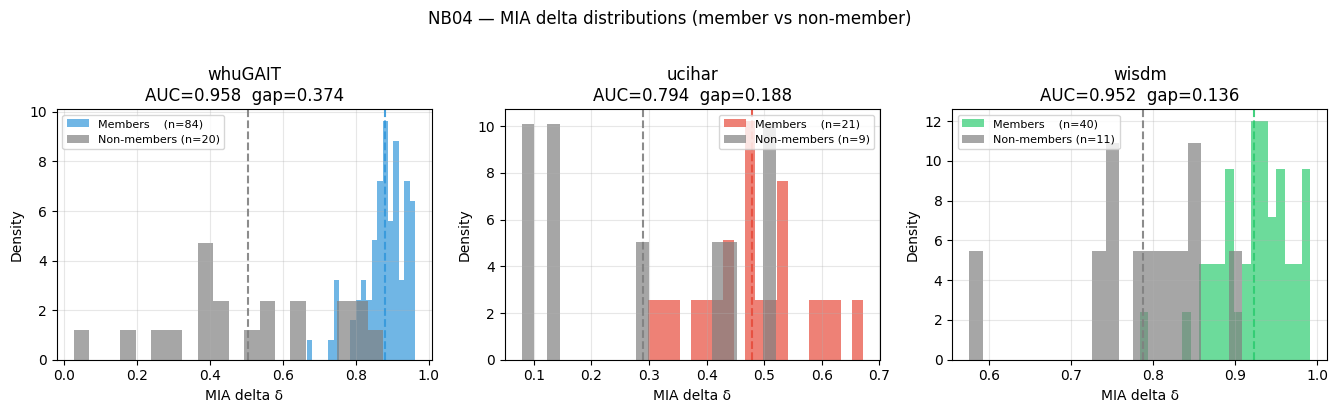

In [ ]:
fig, axes = plt.subplots(1, len(nb04), figsize=(4.5 * len(nb04), 4), sharey=False)
if len(nb04) == 1:
    axes = [axes]

for ax, (ds, data) in zip(axes, nb04.items()):
    c = COLORS[ds]
    ax.hist(data['member_scores'],    bins=20, alpha=0.7, color=c,     label=f'Members    (n={len(data["member_scores"])})', density=True)
    ax.hist(data['nonmember_scores'], bins=20, alpha=0.7, color='grey', label=f'Non-members (n={len(data["nonmember_scores"])})', density=True)
    ax.axvline(data['member_scores'].mean(),    ls='--', color=c,     alpha=0.9)
    ax.axvline(data['nonmember_scores'].mean(), ls='--', color='grey', alpha=0.9)
    ax.set_title(f'{ds}\nAUC={data["mia_auc"]:.3f}  gap={data["delta_gap"]:.3f}')
    ax.set_xlabel('MIA delta δ')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('NB04: MIA delta distributions (member vs non-member)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_nb04_deltas.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. NB05b — LiRA attack variants (grey-box, target-init shadows)

In [ ]:
VARIANTS = ['Simple-D', 'LiRA-raw', 'LiRA-lf', 'LiRA-mf']

nb05b = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / '05b_per_subject_report.json'
    if not path.exists():
        print(f'  {ds}: 05b_per_subject_report.json missing / skipping')
        continue
    with open(path) as f:
        r = json.load(f)
    nb05b[ds] = {v: r['variants'][v] for v in VARIANTS if v in r['variants']}
    for v, m in nb05b[ds].items():
        print(f'  {ds}  {v:12s}  AUC={m["auc"]:.3f}  TPR@10%={m["tpr10"]:.3f}')

In [21]:
# AUC comparison table
auc_data = {}
for v in VARIANTS:
    auc_data[v] = {ds: nb05b[ds][v]['auc'] if ds in nb05b and v in nb05b[ds] else np.nan
                   for ds in DATASETS}

df_auc = pd.DataFrame(auc_data, index=DATASETS)
print('AUC table (rows=datasets, cols=variants):')
print(df_auc.dropna(how='all').round(3).to_string())

tpr_data = {}
for v in VARIANTS:
    tpr_data[v] = {ds: nb05b[ds][v]['tpr10'] if ds in nb05b and v in nb05b[ds] else np.nan
                   for ds in DATASETS}

df_tpr = pd.DataFrame(tpr_data, index=DATASETS)
print('\nTPR@10%FPR table:')
print(df_tpr.dropna(how='all').round(3).to_string())

AUC table (rows=datasets, cols=variants):
         Simple-D  LiRA-raw  LiRA-lf  LiRA-mf
whuGAIT     0.958     0.827    0.653    0.812
ucihar      0.794     0.889    0.815    0.862
wisdm       0.952     0.827    0.723    0.857

TPR@10%FPR table:
         Simple-D  LiRA-raw  LiRA-lf  LiRA-mf
whuGAIT     0.905     0.619    0.214    0.583
ucihar      0.333     0.714    0.667    0.571
wisdm       0.950     0.625    0.525    0.725


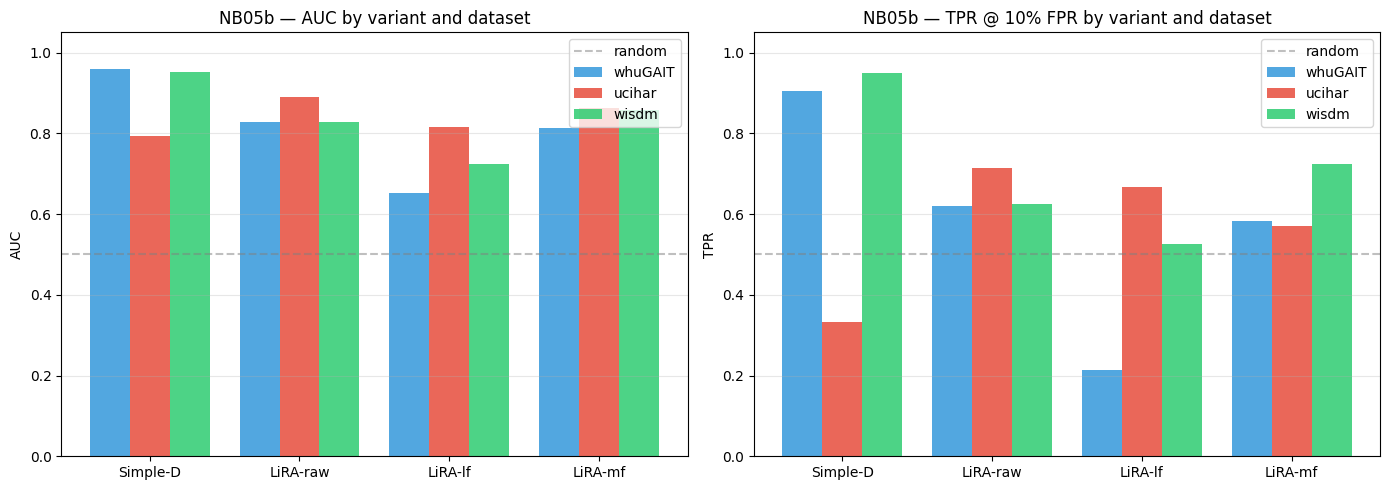

In [ ]:
avail_ds = [ds for ds in DATASETS if ds in nb05b]
x        = np.arange(len(VARIANTS))
width    = 0.8 / max(len(avail_ds), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_plot, title, ylabel) in zip(axes, [
    (df_auc, 'AUC', 'AUC'),
    (df_tpr, 'TPR @ 10% FPR', 'TPR'),
]):
    for i, ds in enumerate(avail_ds):
        vals = [df_plot.loc[ds, v] if v in df_plot.columns else np.nan for v in VARIANTS]
        offset = (i - len(avail_ds)/2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=ds, color=COLORS[ds], alpha=0.85)
    ax.axhline(0.5, ls='--', color='grey', alpha=0.5, label='random')
    ax.set_xticks(x)
    ax.set_xticklabels(VARIANTS)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(ylabel)
    ax.set_title(f'NB05b: {title} by variant and dataset')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_nb05b_lira.png', dpi=150)
plt.show()

## 3. NB05c — Shadow init threat model comparison (grey-box vs warm vs cold)

Three shadow initialisation strategies, ranked by attacker knowledge:
- **Grey-box** (`target-init`): shadows start from the exact target LSTM weights (loaded from NB05b)
- **Black-box warm** (`surrogate-init`): shadows start from an attacker-trained surrogate; attacker knows only architecture + public data
- **Black-box cold** (`random-init`): shadows start from Xavier random init; attacker knows only architecture

Expected ordering by attacker privilege: grey > warm > cold.

In [ ]:
from scipy.stats import norm as sp_norm

def lira_metrics_from_shadow_json(shadow_path, target_deltas_path, threshold=0.5):
    """
    For each subject compute LiRA score = Φ(δ_target; μ_out, σ_out).
    Returns per-variant {'acc': float, 'auc': float}.
    """
    with open(shadow_path) as f:
        shadow = json.load(f)
    td = np.load(target_deltas_path, allow_pickle=True)

    member_ids    = list(td['member_ids'])
    nonmember_ids = list(td['nonmember_ids'])
    all_ids = member_ids + nonmember_ids
    labels  = [1] * len(member_ids) + [0] * len(nonmember_ids)

    results = {}
    for v, td_key in [('raw', 'member_raw'), ('lf', 'member_lf'), ('mf', 'member_mf')]:
        td_v = {**dict(zip(member_ids,    td[td_key])),
                **dict(zip(nonmember_ids, td[f'nonmember_{v}']))}
        per_subj = shadow[v]
        scores, valid_labels = [], []
        for sid, lbl in zip(all_ids, labels):
            deltas = per_subj.get(str(sid), [])
            if len(deltas) < 5 or sid not in td_v:
                continue
            mu    = float(np.mean(deltas))
            sigma = float(np.std(deltas, ddof=1)) + 1e-6
            scores.append(float(sp_norm.cdf(td_v[sid], mu, sigma)))
            valid_labels.append(lbl)
        if len(set(valid_labels)) < 2:
            results[v] = {'acc': np.nan, 'auc': np.nan}
            continue
        preds   = [1 if s >= threshold else 0 for s in scores]
        acc     = sum(p == l for p, l in zip(preds, valid_labels)) / len(valid_labels)
        auc     = roc_auc_score(valid_labels, scores)
        results[v] = {'acc': round(acc, 3), 'auc': round(auc, 3)}
    return results

# ── Grey-box (NB05b per_subject_report) ──────────────────────────────────────
nb05b_metrics = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / '05b_per_subject_report.json'
    if not path.exists():
        print(f'  {ds}: 05b report missing / skipping')
        continue
    with open(path) as f:
        r = json.load(f)
    ps = r['per_subject']
    nb05b_metrics[ds] = {}
    for v in ('Simple-D', 'LiRA-raw', 'LiRA-lf', 'LiRA-mf'):
        valid = [s for s in ps if v in s and s[v].get('score') is not None]
        if len(valid) < 2 or len(set(s['true_label'] for s in valid)) < 2:
            nb05b_metrics[ds][v] = {'acc': float('nan'), 'auc': float('nan')}
            continue
        correct = sum(
            1 for s in valid
            if s[v]['pred'] == ('M' if s['true_label'] == 'member' else 'NM')
        )
        acc = round(correct / len(valid), 3)
        auc = round(roc_auc_score(
            [1 if s['true_label'] == 'member' else 0 for s in valid],
            [s[v]['score'] for s in valid]
        ), 3)
        nb05b_metrics[ds][v] = {'acc': acc, 'auc': auc}
    print(f'  {ds} grey: ' + '  '.join(
        f'{v}=acc{nb05b_metrics[ds][v]["acc"]:.2f}/auc{nb05b_metrics[ds][v]["auc"]:.2f}'
        for v in nb05b_metrics[ds]))

# ── Warm / cold (NB05c shadow JSONs) ─────────────────────────────────────────
nb05c_warm_metrics = {}
nb05c_cold_metrics = {}
for ds in DATASETS:
    td_path   = ARTIFACT_DIR / ds / '05a_target_deltas.npz'
    warm_path = ARTIFACT_DIR / ds / f'05c_lira_warm_shadows_{ds}.json'
    cold_path = ARTIFACT_DIR / ds / f'05c_lira_cold_shadows_{ds}.json'
    if not td_path.exists():
        continue
    if warm_path.exists():
        nb05c_warm_metrics[ds] = lira_metrics_from_shadow_json(warm_path, td_path)
        print(f'  {ds} warm: ' + '  '.join(
            f'{k}=acc{m["acc"]:.2f}/auc{m["auc"]:.2f}' for k, m in nb05c_warm_metrics[ds].items()))
    if cold_path.exists():
        nb05c_cold_metrics[ds] = lira_metrics_from_shadow_json(cold_path, td_path)
        print(f'  {ds} cold: ' + '  '.join(
            f'{k}=acc{m["acc"]:.2f}/auc{m["auc"]:.2f}' for k, m in nb05c_cold_metrics[ds].items()))

### Attack variants explained

#### Official LiRA (Carlini et al., 2022)

The original LiRA operates at the **sample level**. For each training sample `x`:
1. Train K shadow models that include `x` (IN) and K that exclude it (OUT)
2. For each shadow, compute the model's confidence `p = f(x)` (softmax probability of the correct class)
3. Apply the logit transform: `logit(p) = log(p / (1-p))`
4. Fit a Gaussian on the K OUT logit confidences → `(μ_out, σ_out)`
5. Score = `Φ(logit(p_target); μ_out, σ_out)`. how extreme is the target model's confidence relative to the OUT distribution

A member's target confidence tends to be **higher** than the OUT baseline (the model overfits to training samples), so the score is close to 1. A non-member sits inside the OUT distribution, so the score is close to 0.5.

---

#### Our adaptation: why δ instead of raw confidence

Our model is a **pair-based authenticator**, not a classifier. It takes two windows `(x1, x2)` and outputs `P(different person)`. There is no single "correct class confidence" for a subject - membership is expressed across many pairs, not a single sample.

We define the **delta signal** δ as our membership proxy:

> δ(s) = mean P(diff | same-person pairs of s) − mean P(diff | diff-person pairs of s)

A high δ means the authenticator separates same-person from different-person pairs well for subject `s`. Members trained into the model tend to have higher δ than non-members, because the model has seen and fitted to their gait pattern.

We then plug δ into the LiRA framework in place of raw confidence: K shadow models produce OUT-of-bag δ values per subject, we fit a Gaussian, and score with Φ(δ_target; μ_out, σ_out).

---

#### Three δ variants

**Simple-D**: no shadow models. Uses δ_target directly as the attack score. Fast and interpretable, but sensitive to subject-level gait variability: a subject with naturally distinct gait gets a high score regardless of membership.

**LiRA-raw**: shadow framework applied to raw δ. Corrects for subject-level baseline by comparing δ_target to the shadow OUT distribution, but the raw difference may be poorly scaled when pair scores cluster near 0 or 1.

**LiRA-lf** (logit-first): applies the logit transform to **each individual pair score** before computing the mean difference:

> δ_lf(s) = mean logit(P(diff | same-pairs)) − mean logit(P(diff | diff-pairs))

This is the closest adaptation to the original LiRA: the logit is applied per pair before aggregation, stabilising scores at the extremes. A pair where P(diff)=0.99 contributes logit(0.99)≈4.6 rather than 0.99, giving it proportionally more weight.

**LiRA-mf** (mean-first): applies the logit to the **mean** pair score rather than to each pair individually:

> δ_mf(s) = logit(mean P(diff | same-pairs)) − logit(mean P(diff | diff-pairs))

Less sensitive to outlier pairs; more stable when the number of pairs per subject is small. Closer to treating each subject as a single "super-sample".

---

#### Three shadow init strategies (all use member-aware splits)

| Strategy | Init | Attacker knowledge |
|---|---|---|
| Grey-box | Target model weights | Exact model parameters |
| Warm (surrogate) | Self-trained surrogate | Architecture + public gait data only |
| Cold (random) | Xavier random init | Architecture only |

Cold-init shadows are the most independent from the target — their OUT distribution represents a clean "never-seen-this-subject" baseline, which makes the Gaussian fit more discriminating. This is why cold-init achieves higher attack accuracy despite the attacker knowing least.


Accuracy (threshold=0.5):
         Simple-D  LiRA-raw  LiRA-lf  LiRA-mf  warm-raw  warm-lf  warm-mf  cold-raw  cold-lf  cold-mf
dataset                                                                                              
whuGAIT     0.904     0.673    0.346    0.644     0.837    0.740    0.875     0.827    0.827    0.846
ucihar      0.533     0.800    0.767    0.700     0.667    0.267    0.700     0.700    0.700    0.700
wisdm       0.941     0.706    0.608    0.765     0.784    0.627    0.745     0.784    0.784    0.804

AUC:
         Simple-D  LiRA-raw  LiRA-lf  LiRA-mf  warm-raw  warm-lf  warm-mf  cold-raw  cold-lf  cold-mf
dataset                                                                                              
whuGAIT     0.958     0.827    0.653    0.812     0.812    0.749    0.835     0.890    0.925    0.948
ucihar      0.794     0.889    0.815    0.862     0.661    0.481    0.661     0.968    0.921    0.926
wisdm       0.952     0.827    0.723    0.857    

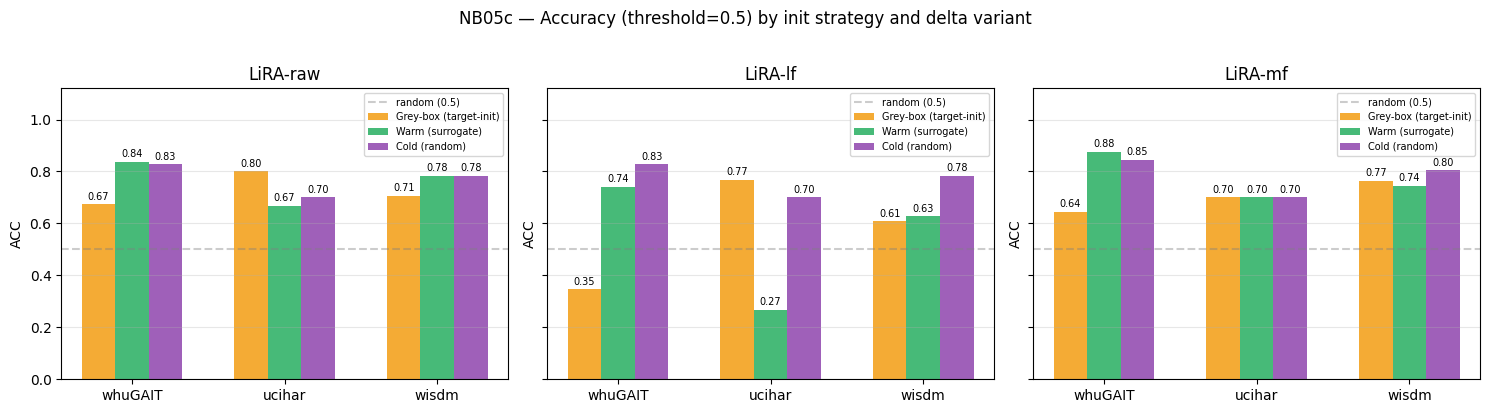

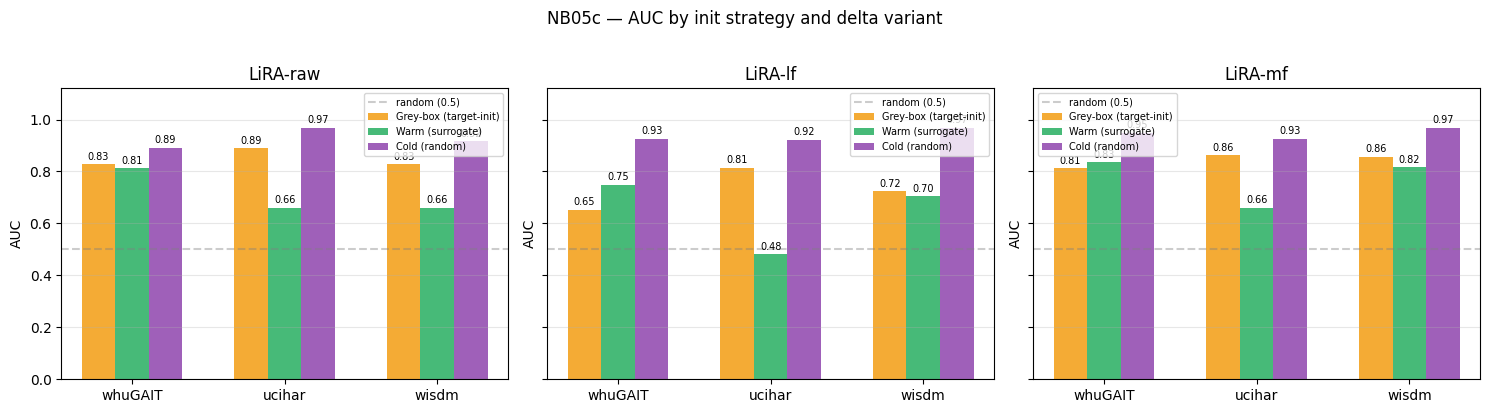

In [ ]:
METHOD_COLS = [
    ('Simple-D',  'grey', 'Simple-D'),
    ('LiRA-raw',  'grey', 'LiRA-raw'),
    ('LiRA-lf',   'grey', 'LiRA-lf'),
    ('LiRA-mf',   'grey', 'LiRA-mf'),
    ('warm-raw',  'warm', 'raw'),
    ('warm-lf',   'warm', 'lf'),
    ('warm-mf',   'warm', 'mf'),
    ('cold-raw',  'cold', 'raw'),
    ('cold-lf',   'cold', 'lf'),
    ('cold-mf',   'cold', 'mf'),
]

def get_metric(ds, src, key, metric):
    if src == 'grey':
        v = nb05b_metrics.get(ds, {}).get(key, {}).get(metric, np.nan)
    elif src == 'warm':
        v = nb05c_warm_metrics.get(ds, {}).get(key, {}).get(metric, np.nan)
    else:
        v = nb05c_cold_metrics.get(ds, {}).get(key, {}).get(metric, np.nan)
    return float(v) if v is not None else np.nan

# Summary tables
for metric, label in [('acc', 'Accuracy (threshold=0.5)'), ('auc', 'AUC')]:
    rows = []
    for ds in DATASETS:
        row = {'dataset': ds}
        for col, src, key in METHOD_COLS:
            row[col] = get_metric(ds, src, key, metric)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('dataset').dropna(how='all')
    print(f'\n{label}:')
    print(df.round(3).to_string())

# Bar charts, one figure for acc, one for auc
LIRA_VS = ['raw', 'lf', 'mf']
avail_ds = [ds for ds in DATASETS
            if ds in nb05b_metrics or ds in nb05c_warm_metrics or ds in nb05c_cold_metrics]
x = np.arange(len(avail_ds))
w = 0.22
INIT_STYLE = [
    ('grey', 'Grey-box (target-init)', '#f39c12'),
    ('warm', 'Warm (surrogate)',        '#27ae60'),
    ('cold', 'Cold (random)',           '#8e44ad'),
]

for metric, fig_label, fname in [
    ('acc', 'Accuracy (threshold=0.5)', 'mia_nb05c_accuracy.png'),
    ('auc', 'AUC',                      'mia_nb05c_auc.png'),
]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, v in zip(axes, LIRA_VS):
        for i, (src, label, color) in enumerate(INIT_STYLE):
            grey_key = f'LiRA-{v}'
            key = grey_key if src == 'grey' else v
            vals = [get_metric(ds, src, key, metric) for ds in avail_ds]
            bars = ax.bar(x + (i - 1) * w, vals, w, label=label, color=color, alpha=0.85)
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f'{val:.2f}', ha='center', va='bottom', fontsize=7)
        baseline = 0.5
        ax.axhline(baseline, ls='--', color='grey', alpha=0.4, label='random (0.5)')
        ax.set_xticks(x)
        ax.set_xticklabels(avail_ds)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel(metric.upper())
        ax.set_title(f'LiRA-{v}')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle(f'NB05c: {fig_label} by init strategy and delta variant', y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc

def get_roc_scores_from_report(report_path, variant='Simple-D'):
    with open(report_path) as f:
        r = json.load(f)
    valid = [s for s in r['per_subject']
             if variant in s and s[variant].get('score') is not None]
    scores = np.array([s[variant]['score'] for s in valid])
    labels = np.array([1 if s['true_label'] == 'member' else 0 for s in valid])
    return scores, labels

def get_roc_scores_from_shadow(shadow_path, td_path, variant='raw'):
    with open(shadow_path) as f:
        shadow = json.load(f)
    td = np.load(td_path, allow_pickle=True)
    member_ids    = list(td['member_ids'])
    nonmember_ids = list(td['nonmember_ids'])
    all_ids = member_ids + nonmember_ids
    labels_all = [1] * len(member_ids) + [0] * len(nonmember_ids)
    td_key = {'raw': 'member_raw', 'lf': 'member_lf', 'mf': 'member_mf'}[variant]
    td_v = {**dict(zip(member_ids,    td[td_key])),
            **dict(zip(nonmember_ids, td[f'nonmember_{variant}']))}
    per_subj = shadow[variant]
    scores, labels = [], []
    for sid, lbl in zip(all_ids, labels_all):
        deltas = per_subj.get(str(sid), [])
        if len(deltas) < 5 or sid not in td_v:
            continue
        mu    = float(np.mean(deltas))
        sigma = float(np.std(deltas, ddof=1)) + 1e-6
        scores.append(float(sp_norm.cdf(td_v[sid], mu, sigma)))
        labels.append(lbl)
    return np.array(scores), np.array(labels)

ATTACK_STYLES = [
    ('Simple-D',    'Simple-$\\delta$',  '#2c3e50', 2.0, '-'),
    ('grey-raw',    'Grey LiRA-raw',      '#f39c12', 1.8, '--'),
    ('grey-lf',     'Grey LiRA-lf',       '#e67e22', 1.4, '--'),
    ('cold-raw',    'Cold LiRA-raw',      '#8e44ad', 1.8, ':'),
    ('cold-lf',     'Cold LiRA-lf',       '#9b59b6', 1.4, ':'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, ds in enumerate(DATASETS):
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], color='grey', lw=0.8, ls=':', alpha=0.5, label='Random (0.500)')

    report_path = ARTIFACT_DIR / ds / '05b_per_subject_report.json'
    td_path     = ARTIFACT_DIR / ds / '05a_target_deltas.npz'
    cold_path   = ARTIFACT_DIR / ds / f'05c_lira_cold_shadows_{ds}.json'

    if not report_path.exists():
        ax.set_title(f'{ds} — no data')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        continue

    for key, label, color, lw, ls in ATTACK_STYLES:
        if key == 'Simple-D':
            scores, labels = get_roc_scores_from_report(report_path, 'Simple-D')
        elif key.startswith('grey-'):
            v = 'LiRA-' + key.split('-')[1]
            scores, labels = get_roc_scores_from_report(report_path, v)
        elif key.startswith('cold-') and td_path.exists() and cold_path.exists():
            v = key.split('-')[1]
            scores, labels = get_roc_scores_from_shadow(cold_path, td_path, v)
        else:
            continue

        if len(set(labels)) < 2 or len(scores) == 0:
            continue
        fpr, tpr, _ = roc_curve(labels, scores)
        a = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{label} ({a:.3f})')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(ds)
    ax.legend(fontsize=7.5, loc='lower right')
    ax.grid(True, alpha=0.25)

plt.suptitle('MIA ROC curves: Simple-delta vs LiRA variants (quick-mode, K=4 shadows)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved mia_roc_comparison.png')


In [ ]:
from src.utils.latex_writer import write_latex_metrics

def _f(v, fmt='.3f'):
    return f'{v:{fmt}}' if isinstance(v, (int, float)) and not np.isnan(float(v)) else '—'

GREY_KEYS = ['Simple-D', 'LiRA-raw', 'LiRA-lf', 'LiRA-mf']
WARM_COLD_KEYS = ['raw', 'lf', 'mf']

for ds in DATASETS:
    if ds not in nb05b_metrics and ds not in nb05c_cold_metrics:
        continue
    metrics = {}
    # Simple delta (NB04)
    if ds in nb04:
        metrics['simplDAUC'] = _f(nb04[ds]['mia_auc'])
        metrics['simplDDeltaGap'] = _f(nb04[ds]['delta_gap'])
    # Grey-box variants
    for v in ['raw', 'lf', 'mf']:
        key = f'LiRA-{v}'
        m = nb05b_metrics.get(ds, {}).get(key, {})
        metrics[f'greyLira{v.capitalize()}ACC'] = _f(m.get('acc', np.nan))
        metrics[f'greyLira{v.capitalize()}AUC'] = _f(m.get('auc', np.nan))
    # Warm variants
    for v in WARM_COLD_KEYS:
        m = nb05c_warm_metrics.get(ds, {}).get(v, {})
        metrics[f'warmLira{v.capitalize()}ACC'] = _f(m.get('acc', np.nan))
        metrics[f'warmLira{v.capitalize()}AUC'] = _f(m.get('auc', np.nan))
    # Cold variants
    for v in WARM_COLD_KEYS:
        m = nb05c_cold_metrics.get(ds, {}).get(v, {})
        metrics[f'coldLira{v.capitalize()}ACC'] = _f(m.get('acc', np.nan))
        metrics[f'coldLira{v.capitalize()}AUC'] = _f(m.get('auc', np.nan))

    prefix = ds.replace('-', '')
    write_latex_metrics(f'compare_mia_{ds}', metrics,
                        output_dir=str(TEX_DIR), key_prefix=prefix)

print(f'LaTeX written to {TEX_DIR}/ (compare_mia_{{ds}}_metrics.tex)')